# Анализ клиентов приложения Zomato

База данных приложения доставки еды представляет собой обширную коллекцию таблиц, в которых хранится вся важная информация, связанная с приложением доставки еды. Она содержит информацию о заказах, сделанных пользователями, продуктах питания, доступных в приложении, меню различных ресторанов, самих ресторанах и пользователях, зарегистрированных в приложении.


#### Задача исследования

На основе анализа данных выделить основной сегмент клиентов и подготовить план действий по удержанию клиентов.

Перед решением задачи понадобится обзор данных. Затем на этапе предобработка данных исправим ошибки.

На этапе исследования данных посмотрим на активность клиентов, количество, сумму заказов, метрики MAU и конверсию в последующие покупки. Выделим основной сегмент клиентов, важный для компании.

В выводе дадим базовые рекомендации по взаимодействия с клиентами и их удержанием.

#### Этапы исследования

1. Обзор данных
2. Предобработка данных
3. Исследовательский анализ данных
4. Вывод

In [530]:
# https://www.kaggle.com/datasets/anas123siddiqui/zomato-database

In [455]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os

In [456]:
path = '/mnt/c/Users/koles/Downloads/datasets/zomato/'

In [457]:
!ls $path

archive.zip  food.csv  menu.csv  orders.csv  restaurant.csv  users.csv


In [458]:
files = [i for i in os.listdir(path) if not i.endswith('.zip')]
files

['food.csv', 'menu.csv', 'orders.csv', 'restaurant.csv', 'users.csv']

# 1. Обзор данных

In [459]:
# функция, которые выводит основную
# информацию про таблицу
def df_info(df: pd.DataFrame) -> None:
    display(df.head())
    display(df.info())
    display(df.describe())
    display(df.isna().sum())
    print('\nКоличество дубликатов', df.duplicated().sum())


# в цикле пройдемся по каждой таблице 
# и посмотрим на нее
dfs = []
for csv in files:
    df = pd.read_csv(path+csv)
    
    if csv == 'users.csv':
        # в данных присутствует приватная
        # информация, удалим ее
        df.drop(['email', 'password'], axis=1, inplace=True)
    
    dfs.append(df)
    print(csv)
    df_info(df)
    print('\n\n')

food.csv


,Unnamed: 0,f_id,item,veg_or_non_veg
0,0,fd0,Aloo Tikki Burger,Veg
1,1,fd1,Veg Creamy Burger,Veg
2,2,fd2,Cheese Burst Burger,Veg
3,3,fd3,Paneer Creamy Burger,Veg
4,4,fd4,Maxican Burger,Veg


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371561 entries, 0 to 371560
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Unnamed: 0      371561 non-null  int64 
 1   f_id            371561 non-null  object
 2   item            371560 non-null  object
 3   veg_or_non_veg  371560 non-null  object
dtypes: int64(1), object(3)
memory usage: 11.3+ MB


None

,Unnamed: 0
count,371561.000000
mean,185780.000000
std,107260.566023
min,0.000000
25%,92890.000000
50%,185780.000000
75%,278670.000000
max,371560.000000


...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   Unnamed: 0                  100000 non-null  int64 
 1   user_id                     100000 non-null  int64 
 2   name                        100000 non-null  object
 3   Age                         100000 non-null  int64 
 4   Gender                      100000 non-null  object
 5   Marital Status              100000 non-null  object
 6   Occupation                  100000 non-null  object
 7   Monthly Income              100000 non-null  object
 8   Educational Qualifications  100000 non-null  object
 9   Family size                 100000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 7.6+ MB


None

,Unnamed: 0,user_id,Age,Family size
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,49999.500000,50000.500000,24.628580,3.280990
std,28867.657797,28867.657797,2.971743,1.349242
min,0.000000,1.000000,18.000000,1.000000
25%,24999.750000,25000.750000,23.000000,2.000000
50%,49999.500000,50000.500000,24.000000,3.000000
75%,74999.250000,75000.250000,26.000000,4.000000
max,99999.000000,100000.000000,33.000000,6.000000


Unnamed: 0                    0
user_id                       0
name                          0
Age                           0
Gender                        0
Marital Status                0
Occupation                    0
Monthly Income                0
Educational Qualifications    0
Family size                   0
dtype: int64


Количество дубликатов 0





### Выводы

Для анализа доступны данные приложения по доставки еды. 

Таблица Orders содержит информацию о заказах, включая дату и время заказа, количество продаж, сумму продаж, валюту, id пользователя и id ресторана.

В таблице Food хранится информация о блюдах, включая их id, название и отметка для вегетарианцев.

Таблица Menu содержит информацию о меню ресторана, включая id меню, id ресторана, id блюда, кухню и цену. 

В таблице Restaurant хранится информация о ресторанах, включая id, название, местоположение, рейтинг, количество оценок, стоимость, кухню, номер лицензии, ссылку на веб-сайт, адрес и меню. 

Таблица Users содержит информацию о пользователях приложения, включая их id, имя, возраст, пол, семейное положение, род занятий, ежемесячный доход, уровень образования и размер семьи. 


#### На этапе предобработки данных нужно будет:

    food.csv
    1. убрать колонку `Unnamed: 0`
    2. в колонках `item` и `veg_or_non_veg` есть один пропуск

    menu.csv
    1. убрать колонку `Unnamed: 0`
    2. исправить тип колонки `price` на `float`

    orders.csv
    1. убрать колонку `Unnamed: 0`
    2. исправить тип колонки `order_date` на `datetime`
    3. в колонке 'r_id' присутствуют пропуски
    4. колонка `sales_qty` имеет аномально высокие значения
    5. колонка `sales_amount` имеет аномально высокие и отрицательные значения значения

    restarant.csv
    1. убрать колонку `Unnamed: 0`
    2. исправить тип колонки `cost` на `float`
    3. исправить тип колонки `rating` на `float`
    3. в колонках `name`, `rating`, `rating_count`, `cost`, `cuisine`, `lic_no`, `address` есть пропуски

    users.csv
    1. убрать колонку `Unnamed: 0`
    2. изменить стиль написания колонок

# 2. Предобработка данных

In [460]:
# сохраним датафреймы в переменные
food, menu, orders, restarant, users = dfs

**food**

In [461]:
# удалим колонку 'Unnamed: 0' в таблице 'food'
food = food.drop('Unnamed: 0', axis=1)

In [462]:
food.head()

,f_id,item,veg_or_non_veg
0,fd0,Aloo Tikki Burger,Veg
1,fd1,Veg Creamy Burger,Veg
2,fd2,Cheese Burst Burger,Veg
3,fd3,Paneer Creamy Burger,Veg
4,fd4,Maxican Burger,Veg


**menu**

In [463]:
# удалим колонку 'Unnamed: 0' в таблице 'menu'
menu = menu.drop('Unnamed: 0', axis=1)

In [464]:
# исправим тип колонки 'price' с 'object' на 'float'

# для начала посмотрим наличеи не числовых значений
# в колонке 'price'
pd.to_numeric(menu.price, errors='coerce').isna().sum()

1193

In [465]:
# всего таких значений 1193. 

# посмотрим на уникальные не числовые значения
# в колонке `price`
menu[pd.to_numeric(menu.price, errors='coerce').isna()].price.unique()

array(['₹200 FOR TWO', '₹350 FOR TWO', '₹400 FOR TWO', '₹500 FOR TWO',
       '₹300 FOR TWO', '₹199 FOR TWO', '₹250 FOR TWO', '₹150 FOR TWO',
       '₹600 FOR TWO', '₹100 FOR TWO', '₹1200 FOR TWO', '₹60 FOR TWO',
       '₹550 FOR TWO', '₹99 FOR TWO', '₹450 FOR TWO', '₹800 FOR TWO',
       '₹280 FOR TWO', '₹700 FOR TWO', '₹130 FOR TWO', '₹70 FOR TWO',
       '₹1000 FOR TWO', '₹125 FOR TWO', '₹120 FOR TWO', '₹90 FOR TWO',
       '₹180 FOR TWO', '₹850 FOR TWO', '₹50 FOR TWO', '₹399 FOR TWO',
       '₹1245 FOR TWO', '₹900 FOR TWO', '₹299 FOR TWO', '₹1500 FOR TWO',
       '₹290 FOR TWO', '₹149 FOR TWO', '₹160 FOR TWO', '₹650 FOR TWO',
       '₹330 FOR TWO', '₹80 FOR TWO', '₹1800 FOR TWO', '₹220 FOR TWO',
       '₹110 FOR TWO', '₹460 FOR TWO', '₹5 FOR TWO', '₹170 FOR TWO'],
      dtype=object)

In [466]:
# похоже на акционное предложение
# от приложения или ресторана

# чтоб не потерять информацию об
# этом предложении, создадим колонку с
# бинарной переменной, где 1 это предложение "FOR TWO"
menu['price_for_two'] = np.zeros(menu.shape[0])
menu.loc[pd.to_numeric(menu.price, errors='coerce').isna(), 'price_for_two'] = 1
menu['price_for_two'] = menu['price_for_two'].astype('int')

In [467]:
# проверим правильность выполнених действий
menu.price_for_two.sum(), pd.to_numeric(menu.price, errors='coerce').isna().sum()

(1193, 1193)

In [468]:
# уберем знак валюты и слова "FOR TWO"
changed_price = menu[pd.to_numeric(menu.price, errors='coerce').isna()] \
                    .price.apply(lambda x: x.split()[0][1:])

# проверим правильность выполнених действий
display(changed_price.unique(), \
            menu[pd.to_numeric(menu.price, errors='coerce').isna()].price.unique())

array(['200', '350', '400', '500', '300', '199', '250', '150', '600',
       '100', '1200', '60', '550', '99', '450', '800', '280', '700',
       '130', '70', '1000', '125', '120', '90', '180', '850', '50', '399',
       '1245', '900', '299', '1500', '290', '149', '160', '650', '330',
       '80', '1800', '220', '110', '460', '5', '170'], dtype=object)

array(['₹200 FOR TWO', '₹350 FOR TWO', '₹400 FOR TWO', '₹500 FOR TWO',
       '₹300 FOR TWO', '₹199 FOR TWO', '₹250 FOR TWO', '₹150 FOR TWO',
       '₹600 FOR TWO', '₹100 FOR TWO', '₹1200 FOR TWO', '₹60 FOR TWO',
       '₹550 FOR TWO', '₹99 FOR TWO', '₹450 FOR TWO', '₹800 FOR TWO',
       '₹280 FOR TWO', '₹700 FOR TWO', '₹130 FOR TWO', '₹70 FOR TWO',
       '₹1000 FOR TWO', '₹125 FOR TWO', '₹120 FOR TWO', '₹90 FOR TWO',
       '₹180 FOR TWO', '₹850 FOR TWO', '₹50 FOR TWO', '₹399 FOR TWO',
       '₹1245 FOR TWO', '₹900 FOR TWO', '₹299 FOR TWO', '₹1500 FOR TWO',
       '₹290 FOR TWO', '₹149 FOR TWO', '₹160 FOR TWO', '₹650 FOR TWO',
       '₹330 FOR TWO', '₹80 FOR TWO', '₹1800 FOR TWO', '₹220 FOR TWO',
       '₹110 FOR TWO', '₹460 FOR TWO', '₹5 FOR TWO', '₹170 FOR TWO'],
      dtype=object)

In [469]:
# сохраним отредактированные записи
# и изменим тип переменной на `float`
menu.loc[pd.to_numeric(menu.price, errors='coerce').isna(), 'price'] = changed_price
menu['price'] = menu['price'].astype('float')

**orders**

In [470]:
# удалим колонку 'Unnamed: 0' в таблице 'orders'
orders = orders.drop('Unnamed: 0', axis=1)

In [471]:
# изменим тип колонки `order_date` на `datetime`
orders['order_date'] = pd.to_datetime(orders['order_date'])

In [472]:
# посмотрим на пропуски в колонке `r_id`
orders[orders.r_id.isna()]

,order_date,sales_qty,sales_amount,currency,user_id,r_id
148664,2019-03-19,1,1625,INR\r,50862,NaN
148665,2019-03-19,1,1741,INR\r,25120,NaN
148666,2019-03-20,1,1463,INR\r,84260,NaN
148667,2019-03-20,1,2949,INR\r,14329,NaN
148668,2019-03-21,1,1241,INR\r,38858,NaN
...,...,...,...,...,...,...
150276,2019-04-18,1,394,INR\r,79856,NaN
150277,2019-04-23,1,667,INR\r,65798,NaN
150278,2019-04-23,1,625,INR\r,49176,NaN
150279,2019-04-24,7,8625,INR\r,87924,NaN


In [473]:
# всего таких значений 1617 что примерно 1%

# восстановить пропуски или заменить их на
# популярные r_id среди пользователей, у которых
# есть пропуски мы не можем, поэтому оставляем как есть

In [474]:
# посмотрим на выбросы в колонке `sales_qty`
orders.sales_qty.describe()

count    150281.000000
mean         16.264997
std         114.761496
min           1.000000
25%           1.000000
50%           1.000000
75%           7.000000
max       14049.000000
Name: sales_qty, dtype: float64

In [475]:
orders.sort_values('sales_qty', ascending=False).head(20)

,order_date,sales_qty,sales_amount,currency,user_id,r_id
22034,2019-11-29,14049,628657,INR\r,60046,416409.0
21805,2019-01-25,10667,534463,INR\r,78855,407770.0
21547,2018-02-08,10667,450954,INR\r,58535,385543.0
21663,2018-07-23,10667,534463,INR\r,43819,537634.0
63986,2018-01-31,8800,647778,INR\r,66926,542825.0
21313,2020-02-29,8000,38889,INR\r,97856,286268.0
21990,2019-09-30,6667,298310,INR\r,71745,493031.0
21314,2020-04-14,6000,29167,INR\r,73359,230460.0
21606,2018-05-04,5333,267231,INR\r,15848,504000.0
21593,2018-04-18,5333,267231,INR\r,69218,480220.0


In [476]:
q1 = orders.sales_qty.quantile(0.25)
q3 = orders.sales_qty.quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + iqr * 1.5

print('Количество строк с выбросами - {:.3f}\n'
      'Количество уникальных пользователей, котрые оформили большие заказы - {:.3f}\n'.format(
            orders[orders.sales_qty > upper_bound].shape[0] / orders.shape[0],
            orders[orders.sales_qty > upper_bound]['user_id'].nunique() / orders['user_id'].nunique()
))

Количество строк с выбросами - 0.148
Количество уникальных пользователей, котрые оформили большие заказы - 0.255



In [477]:
# количество строк с аномальными значениями в
# колонке `sales_qty` достигает 14.8%,
# каждый четвертый пользователь
# делал большоке количество заказов

In [478]:
# посмотрим на значения меньше,
# либо равные нулю в колонке `sales_amount`

orders[orders.sales_amount <= 0]

,order_date,sales_qty,sales_amount,currency,user_id,r_id
1,2018-05-08,3,-1,INR,77359,531342.0
159,2018-05-26,1,0,INR,59836,102582.0
196,2019-04-30,1,0,INR,95267,553404.0
239,2018-12-28,1,0,INR,14159,499377.0
282,2018-05-08,3,-1,INR\r,357,509389.0
...,...,...,...,...,...,...
148969,2019-08-16,1,0,INR\r,13971,NaN
149017,2019-09-09,1,0,INR\r,21153,NaN
149053,2019-09-26,2,0,INR\r,17856,NaN
149164,2019-11-19,1,0,INR\r,64848,NaN


In [479]:
# если значения -1 больше похоже на ошибку в данных и их нужно удалить, то
# значения равные 0 могут быть промо акцией для привлечения пользователей

# посмотрим на количество таких строк и на количество уникальных пользователей в них
orders[orders.sales_amount == 0].shape, orders[orders.sales_amount == 0]['user_id'].nunique()

((1609, 6), 1592)

In [480]:
# гипотеза не подтвердилась, есть 17 пользователей,
# которые оформляли заказ на сумму 0 валюты больше одного раза,
# похоже на ошибку в данных, удалим эти строки

i = orders[orders.sales_amount <= 0].index
orders.drop(i, inplace=True)

In [481]:
# проверка

orders.sales_amount.describe()

count    1.486700e+05
mean     6.635939e+03
std      3.007124e+04
min      5.000000e+00
25%      1.760000e+02
50%      5.190000e+02
75%      3.065000e+03
max      1.510944e+06
Name: sales_amount, dtype: float64

In [482]:
# теперь минимальное значение равно 5

**restarant**

In [483]:
# удалим колонку 'Unnamed: 0' в таблице 'restarant'
restarant = restarant.drop('Unnamed: 0', axis=1)

In [484]:
restarant.head()

,id,name,city,rating,rating_count,cost,cuisine,lic_no,link,address,menu
0,567335,AB FOODS POINT,Abohar,--,Too Few Ratings,₹ 200,"Beverages,Pizzas",22122652000138,https://www.swiggy.com/restaurants/ab-foods-po...,"AB FOODS POINT, NEAR RISHI NARANG DENTAL CLINI...",Menu/567335.json
1,531342,Janta Sweet House,Abohar,4.4,50+ ratings,₹ 200,"Sweets,Bakery",12117201000112,https://www.swiggy.com/restaurants/janta-sweet...,"Janta Sweet House, Bazar No.9, Circullar Road,...",Menu/531342.json
2,158203,theka coffee desi,Abohar,3.8,100+ ratings,₹ 100,Beverages,22121652000190,https://www.swiggy.com/restaurants/theka-coffe...,"theka coffee desi, sahtiya sadan road city",Menu/158203.json
3,187912,Singh Hut,Abohar,3.7,20+ ratings,₹ 250,"Fast Food,Indian",22119652000167,https://www.swiggy.com/restaurants/singh-hut-n...,"Singh Hut, CIRCULAR ROAD NEAR NEHRU PARK ABOHAR",Menu/187912.json
4,543530,GRILL MASTERS,Abohar,--,Too Few Ratings,₹ 250,"Italian-American,Fast Food",12122201000053,https://www.swiggy.com/restaurants/grill-maste...,"GRILL MASTERS, ADA Heights, Abohar - Hanumanga...",Menu/543530.json


In [485]:
# изменим тип колонки 'cost' на 'float'

# сначало проверим вхождение знака валюты
# в строки, кроме Nan
restarant[~restarant.isna()].cost.str.contains('₹').all()

True

In [486]:
# теперь удалим знак валюты и
# изменим тип колонки
restarant.loc[~restarant.cost.isna(), 'cost'] = restarant[~restarant.cost.isna()].cost.apply(lambda x: x.split()[-1])
restarant['cost'] = restarant['cost'].astype('float')

In [487]:
# изменим тип колонки 'cost' на 'float'

restarant.rating.value_counts()[:5]

--     87014
4.0     6532
4.1     6296
4.2     5821
3.8     5736
Name: rating, dtype: int64

In [488]:
# у половины всех записей отсутствует оценка,
# чем-то заменить пропуск невозможно, пропустим
# эту колонку

In [489]:
restarant.isna().sum()

id                0
name             86
city              0
rating           86
rating_count     86
cost            131
cuisine          99
lic_no          229
link              0
address          86
menu              0
dtype: int64

In [490]:
restarant[~restarant.cost.isna()].cost.astype('float').describe()

count    148410.000000
mean        287.600714
std         796.730688
min           1.000000
25%         200.000000
50%         250.000000
75%         300.000000
max      300350.000000
Name: cost, dtype: float64

In [491]:
# заменим пропуски в колонка 'rating_count', 'cuisine'
# на самые популярные значения,
# в колонке 'cost', за счет небольшого количества
# больших значений, дисперсия очень большая,
# по этому пропуски заменим на медиану

In [492]:
def fill_na(df, columns):
    for col in columns:
        if df[col].dtype == 'O':
            x = df.groupby(col).count().iloc[:, 0].sort_values(ascending=False).index[0]
        elif df[col].dtype == 'float64':
            x = df[col].median()
        else:
            print(col, 'error')
            continue
        
        df[col].fillna(x, inplace=True)

In [493]:
fill_na(restarant, ['rating_count', 'cuisine', 'cost'])

In [494]:
restarant.isna().sum()

id                0
name             86
city              0
rating           86
rating_count      0
cost              0
cuisine           0
lic_no          229
link              0
address          86
menu              0
dtype: int64

**users**

In [495]:
# удалим колонку 'Unnamed: 0' в таблице 'users'
users = users.drop('Unnamed: 0', axis=1)

In [496]:
# изменим стиль написания колонок
users.columns = ['_'.join(i.lower().split()) for i in users.columns]

users.head()

,user_id,name,age,gender,marital_status,occupation,monthly_income,educational_qualifications,family_size
0,1,Claire Ferguson,20,Female,Single,Student,No Income,Post Graduate,4
1,2,Jennifer Young,24,Female,Single,Student,Below Rs.10000,Graduate,3
2,3,Jermaine Roberson,22,Male,Single,Student,Below Rs.10000,Post Graduate,3
3,4,Rachel Carpenter,22,Female,Single,Student,No Income,Graduate,6
4,5,Shawn Parker,22,Male,Single,Student,Below Rs.10000,Post Graduate,4


### Выводы

На этапе предобработки данных мы удалили лишние колонки, изменили типы колонок, заменили пропуски.

# 3. Исследовательский анализ данных

In [529]:
# посчитаем количество клиентов, которые 
# хотя бы один раз сделали заказ и среднее
# количество заказов на одного клиента

(
    orders.user_id.nunique(),
    orders.shape[0], 
    round(orders.shape[0] / orders.user_id.nunique(), 1)
)

(77584, 148670, 1.9)

In [498]:
(
    orders.order_date.min(), orders.order_date.max(),
    (orders.order_date.max() - orders.order_date.min()).days
)

(Timestamp('2017-10-04 00:00:00'), Timestamp('2020-06-26 00:00:00'), 996)

In [499]:
# За период 2017-10-04 по 2020-06-26 или 996 дней
# было совершенно 148670 заказов. Всего за этот период
# были активны 77584 клиентов. Среднее количество заказов
# на одного клиента равняется 1.9.

In [500]:
# Посчитаем метрику MAU и сравним
# её с показателями предыдущих годов

In [501]:
def mau(df: pd.DataFrame, year: int) -> pd.DataFrame:
    df = df[df.order_date.dt.year == year]
    df['month'] = df.order_date.dt.month
    
    return df.groupby('month').nunique().user_id

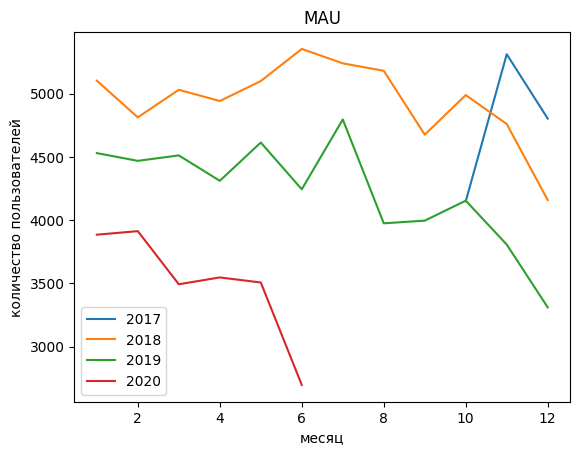

In [502]:
orders_copy = orders.copy()
years = orders.order_date.apply(lambda x: x.year).unique()

fig, ax = plt.subplots()

for i in years:
    m = mau(orders_copy, i)
    ax.plot(m, label=i)
    
ax.set_title('MAU')
ax.set_xlabel('месяц')
ax.set_ylabel('количество пользователей')

ax.legend()

plt.show();

In [503]:
# На графике видно:
#     1. в начале 2017, когда появилось приложение, был рост, после которого
#         метрика вышла на плато до августа 2018 года, возможно имело место
#         быть промо акции либо обширная маркетинговая компания
#     2. после августа 2018, метрика начала проявлять тенденцию к снижению,
#         которое продлилось до июня 2020 года
#     3. после 06.2020 данных нет

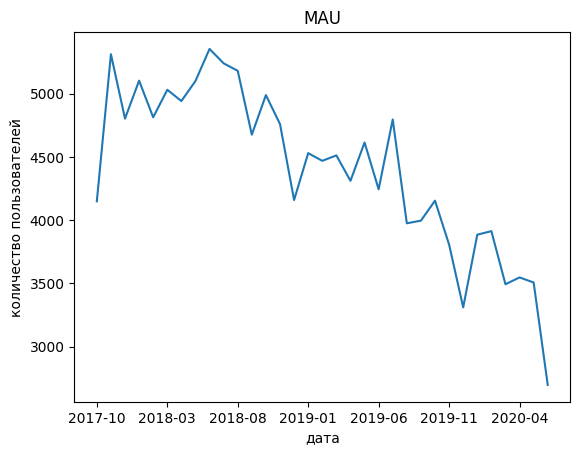

In [504]:
# посмотрим общий график метрики MAU от начала и до конца

fig, ax = plt.subplots()

orders['year_month'] = orders.order_date.dt.strftime('%Y-%m')
mau = orders.groupby('year_month').nunique()['user_id']

ax.plot(mau)

plt.title('MAU')
plt.xlabel('дата')
plt.ylabel('количество пользователей')

plt.xticks(ax.get_xticks()[::5])

plt.show();

In [505]:
# Теперь тренд к падению MAU более заметен 

# Посмотрим на поведение метрики у разных клиентов

In [506]:
def line_chart_by_category(df: pd.DataFrame, base_column: str, columns: np.array, 
                             agg_funcs: list, axis_shape: tuple, suptitle: str) -> None:
    r, c = axis_shape
    fig, axs = plt.subplots(r, c, figsize=(14, 10))
    axs = axs.flatten()
        
    for index, column in enumerate(columns):
        table = df.groupby(['year_month', column]).agg(agg_funcs)[base_column].unstack().droplevel(0, axis=1)
        
        axs[index].plot(table)
        axs[index].legend(table.columns)
        axs[index].set(title=column, xticks=axs[index].get_xticks()[::10])
    
    plt.suptitle(suptitle)
    plt.show()

In [507]:
users.age.min(), users.age.max()

(18, 33)

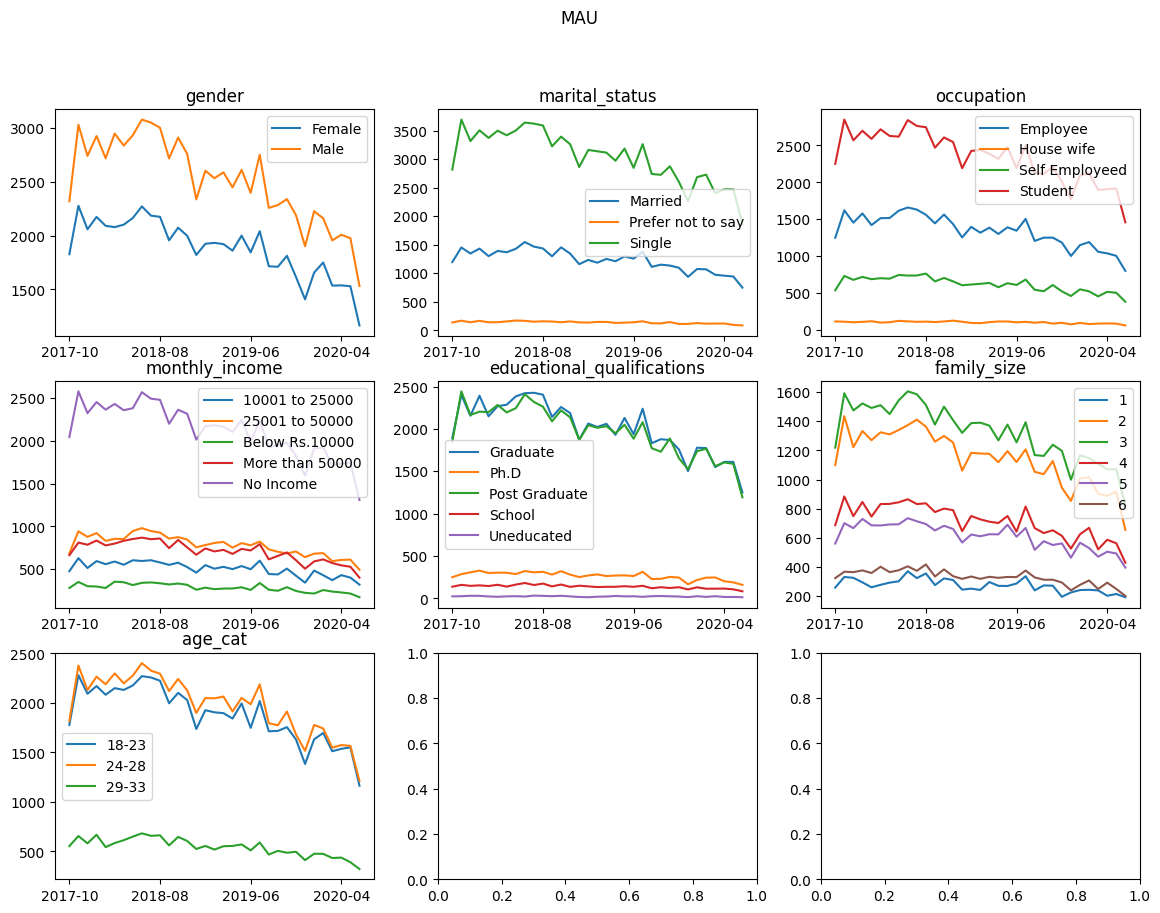

In [508]:
orders_users = pd.merge(orders, users, how='left', on='user_id')
orders_users['year_month'] = orders_users.order_date.dt.strftime('%Y-%m')
orders_users['age_cat'] = pd.cut(orders_users.age, 
                                 bins=[17, 23, 28, 33], 
                                 labels=['18-23', '24-28', '29-33'])

add_columns = np.array([
    'gender', 'marital_status', 'occupation', 
    'monthly_income', 'educational_qualifications', 
    'family_size', 'age_cat'
])

line_chart_by_category(orders_users, 'user_id', 
                       add_columns, ['nunique'], 
                       (3, 3), 'MAU')

In [509]:
# Основываясь на графиках, можно выделить типичного клиента:
#     - мужчина
#     - не женат/в отношениях
#     - получающий высшее образование
#     - не имеющий доходов
#     - выпускных курсов
#     - 18-28 лет
#     - с размером семьи 2-3 (сложно трактовать эту категорию так, как не понятно
#                            про какую семью идет речь: либо муж/жена и дети, либо
#                            брат/сестра и родители)

# Именно это категория клиентов самая массовая и в тоже время их активность быстрее всех падает. 
# Другие категории либо не так быстро падают, либо выходят на плато и держатся.

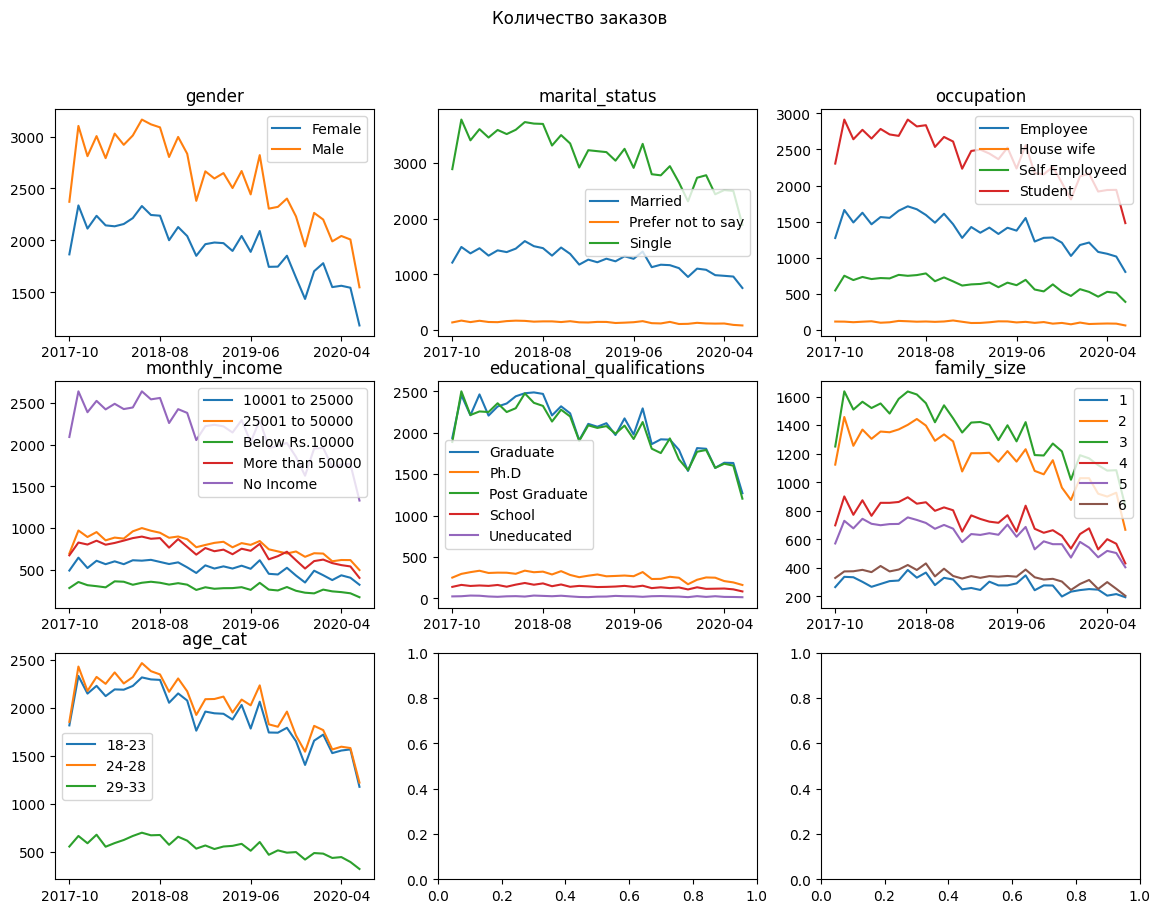

In [510]:
# посмотрим на количество заказов ежемесячно

line_chart_by_category(orders_users, 'sales_qty', 
                       add_columns, ['count'], 
                       (3, 3), 'Количество заказов')

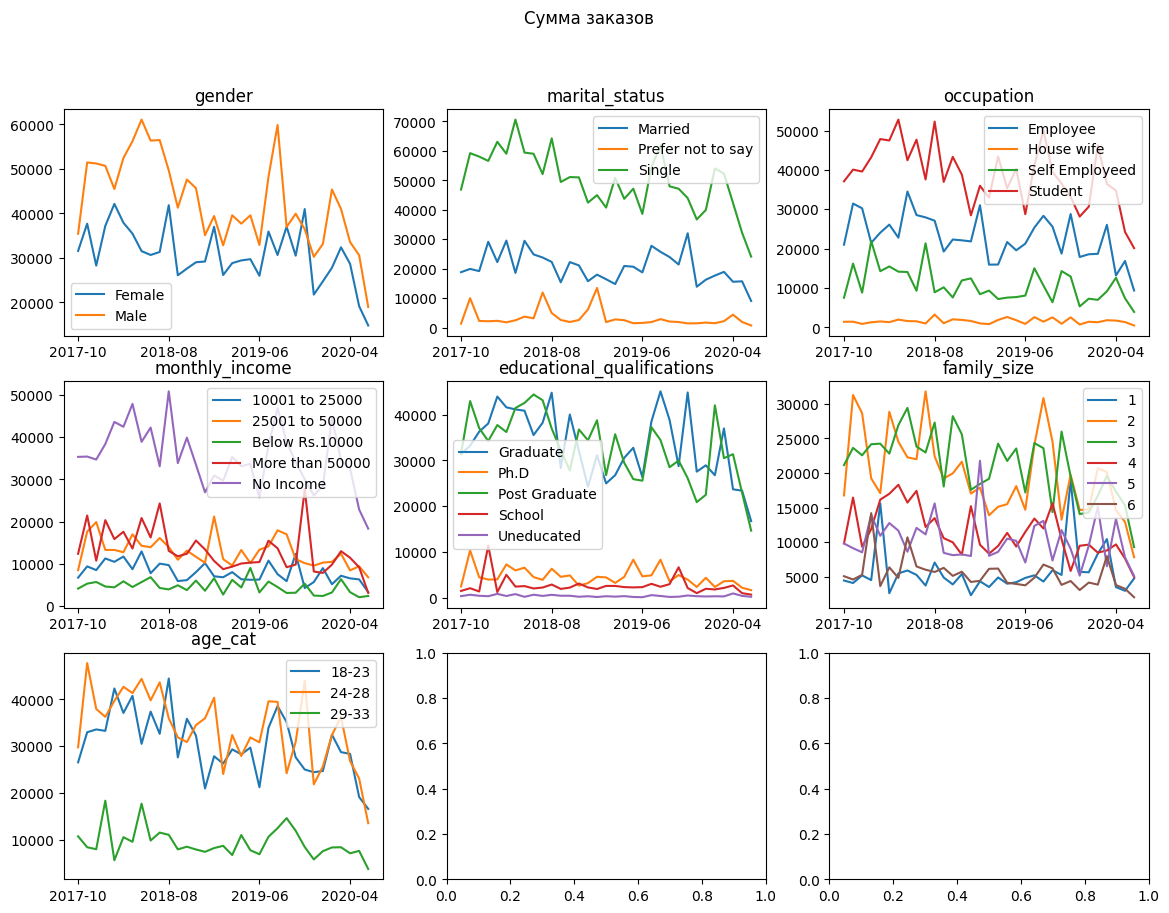

In [511]:
# и на сумму заказов ежемесячно

line_chart_by_category(orders_users, 'sales_qty', 
                       add_columns, ['sum'], 
                       (3, 3), 'Сумма заказов')

In [512]:
# Если количество заказов ежемесячно падает, как и метрика
# MAU, то сумма заказо, в некоторыех категориях, колебается
# +- в одних значения. Например: "в браке" в категории "семейный статус",
# "нанятый сотрудник" "самозаннятый" в категории "профессия", 
# "выпоскник" "аспирант" в категории "образование".

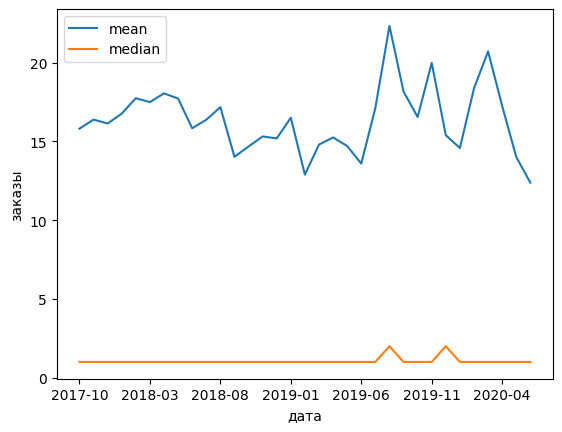

In [513]:
# посмотрим среднее и медианное значение заказов ежемесячно

fig, ax = plt.subplots()

mean_sum_sales = orders.groupby('year_month').mean()['sales_qty']
median_sum_sales = orders.groupby('year_month').median()['sales_qty']

ax.plot(mean_sum_sales, label='mean')
ax.plot(median_sum_sales, label='median')

plt.legend()
plt.xlabel('дата')
plt.ylabel('заказы')

plt.xticks(ax.get_xticks()[::5])

plt.show();

In [514]:
date_border = '2019-06'
display(orders[orders.year_month <= date_border].groupby('year_month').mean()['sales_qty'].agg(['min', 'max']),
    orders[orders.year_month > date_border].groupby('year_month').mean()['sales_qty'].agg(['min', 'max']))

min    12.892045
max    18.052580
Name: sales_qty, dtype: float64

min    12.385573
max    22.334896
Name: sales_qty, dtype: float64

In [515]:
# До июня 2019 года среднее значение колебалось в диапазоне 12.9-18.05 заказов,
# после верхняя планка увеличилась до 22.33. Это показывает, что появилось больше
# клиентов, которые делают более обьемные заказы.

# Обращаясь к предыдущим выводам, можно сделать вывод, что после июня 2019 появилась 
# категория клиентов, которые делают заказы на какие-то события для большого
# количества людей.

# Медианное значение держиться в районе 1, это значит, что основная часть
# клиентов продолжает делает небольшие заказы.

In [516]:
# посмотрим какая часть составляет клиенты, которые делают обьемные заказы

q1 = orders.sales_qty.quantile(0.25)
q3 = orders.sales_qty.quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + iqr * 1.5

upper_bound, orders[orders.sales_qty > upper_bound].shape[0] / orders.shape[0]

(16.0, 0.1485975650770162)

In [517]:
# Примерно у 15% клиентов количество продуктов в одном заказе
# больше 16, то есть количество продуктов в одном заказе
# выбиваетя из общей картины среди всех пользователей

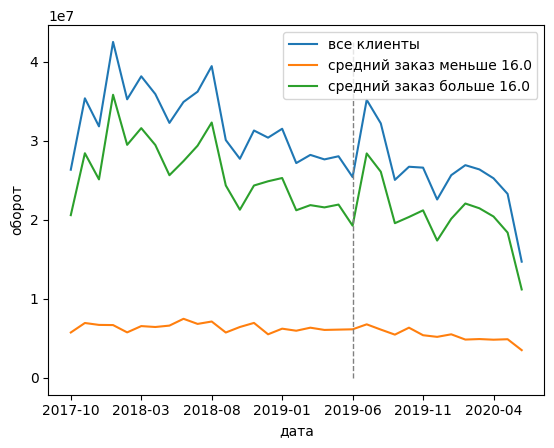

In [518]:
# посмотрим на оборот денег в зависимости от среднего заказа

fig, ax = plt.subplots()

all_time = orders.groupby('year_month').sum()['sales_amount']
sales_qty_lower_bound = orders[orders.sales_qty <= upper_bound].groupby('year_month').sum()['sales_amount']
sales_qty_upper_bound = orders[orders.sales_qty > upper_bound].groupby('year_month').sum()['sales_amount']

ax.plot(all_time, label='все клиенты')
ax.plot(sales_qty_lower_bound, label=f'средний заказ меньше {upper_bound}')
ax.plot(sales_qty_upper_bound, label=f'средний заказ больше {upper_bound}')

ax.vlines(date_border, 0, all_time.max(), color='grey', 
          linestyle='--', linewidth=1)

plt.legend()
plt.xlabel('дата')
plt.ylabel('оборот')

plt.xticks(ax.get_xticks()[::5])

plt.show();

In [519]:
display(orders[orders.sales_qty > upper_bound].sales_amount.sum() / orders.sales_amount.sum(),
    orders[orders.sales_qty <= upper_bound].sales_amount.sum() / orders.sales_amount.sum())

0.798908315843001

0.20109168415699896

In [520]:
# Видно что ~80% оборота делают ~15% клиентов и оборот все время падает.

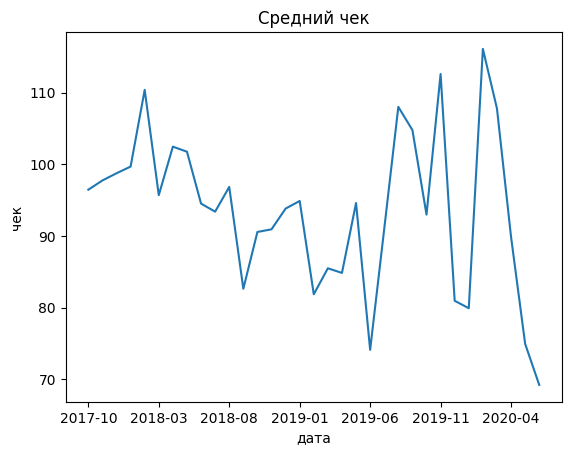

In [521]:
# посмотрим на средний чек у клиентов, которые
# оформляют большие заказы

fig, ax = plt.subplots()

aov = orders[orders.sales_qty > upper_bound].groupby('year_month').mean()['sales_qty']

ax.plot(aov)

plt.title('Средний чек')
plt.xlabel('дата')
plt.ylabel('чек')

plt.xticks(ax.get_xticks()[::5])

plt.show();

In [527]:
# До 2019-06 видна тенденция к снижению среднего чека. 
# После метрика вышла на плато, но её начало сильнее колебать от
# месяца к месяцу. Это результат того, что средний чек зависит от небольшого
# числа клиентов.

In [523]:
# посчитаем конверсию в n покупку у крупных клиентов

orders_big_clients = orders.copy()[orders.sales_qty > upper_bound]

orders_big_clients['cr'] = orders_big_clients.sort_values('order_date') \
                                                .groupby('user_id').cumcount() + 1

cr_bc = pd.pivot_table(orders_big_clients, values='r_id', index='user_id',
                    columns='cr', aggfunc=lambda x: 1, fill_value=0).mean()

cr_bc

cr
1    1.000000
2    0.107046
3    0.007621
4    0.000303
dtype: float64

In [528]:
# посчитаем конверсию в n покупку у небольших клиентов

orders_small_clients = orders.copy()[orders.sales_qty <= upper_bound]

orders_small_clients['cr'] = orders_small_clients.sort_values('order_date') \
                                                    .groupby('user_id').cumcount() + 1

cr_sc = pd.pivot_table(orders_small_clients, values='r_id', index='user_id',
                    columns='cr', aggfunc=lambda x: 1, fill_value=0).mean()

cr_sc

cr
1    1.000000
2    0.502680
3    0.184764
4    0.054141
5    0.012886
6    0.002638
7    0.000458
8    0.000069
dtype: float64

In [525]:
cr_sc[:4] / cr_bc

cr
1      1.000000
2      4.695946
3     24.244528
4    178.790792
dtype: float64

In [526]:
# Конверсия в последующие покупки для больших клиентов очень мала.
# Для сравнения, у небольших клиентов конверсия во вторую покупку в 4.7 раза больше,
# в третью покупку в 24.2 раза больше, в четвертую в 179 раз больше.

# 4. Выводы

За период 2017-10-04 по 2020-06-26 было совершенно **148670 заказов**. Всего за этот период были активны **77584 клиентов**. Среднее количество заказов на одного клиента равняется **1.9**.

До августа 2018 метрика MAU **росла либо не падала**. После августа 2018 метрика показывает **тенденцию к падению**.

Типичный клиент: мужчина, не женат/в отношениях, получает высшее образование, не имеет доходов, выпускных курсов, возраст 18-28 лет, размер семьи 2-3 (сложно трактовать эту категорию так, как не понятно про какую семью идет речь: либо муж/жена и дети, либо брат/сестра и родители).

Сумма заказов, в некоторых категориях, колеблется +- в одних значения. Например: "в браке" в категории "семейный статус", "нанятый сотрудник" и "самозанятый" в категории "профессия",  "выпускник" и "аспирант" в категории "образование".

Примерно у **15% клиентов** количество продуктов в одном заказе **больше 16**, что является аномальным значением на фоне всех клиентов. Именно эти клиенты делают **80% оборота** денежных средств для приложения.

Конверсия в последующие покупки для больших клиентов **крайне мала**. Для сравнения, у небольших клиентов конверсия во вторую покупку в **4.7 раза больше**, в третью в **24.2 раза больше**, в четвертую в **179 раз больше**.

**Рекомендации:**
1. конверсия в последующие покупки у крупных клиентов крайне мала, для них нужно обеспечить приятные акционные предложения / накопительные системы скидок / бесплатную доставку, все это для того чтоб увеличить привлекательность последующих покупок
2. провести маркетинговую компанию, нацеленную на крупных клиентов (госучреждения, компаниии, учебные заведения), обеспечить выгодные условия для первого заказа и создать условия для удержания для последующих заказов